<a href="https://colab.research.google.com/github/shahzamanjatoi/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shahzamanjatoi/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)
# Capstone — February Search Signals for Future Zero-Click Risk

## FlyRank ML Internship Capstone

This capstone presents an end-to-end machine-learning workflow for identifying content items that are more likely to receive **zero clicks in the following month**.

The project uses February search-performance signals to predict March zero-click risk. It covers data preparation, feature engineering, leakage-safe client-level validation, baseline comparison, logistic regression modeling, error analysis, and ranked recommendations.

The final model is compared with the Week-4 baseline using **Precision@10, Precision@20, and Precision@50**. The results are then converted into a practical review queue for content investigation and monitoring.

**Key result:** the logistic regression model achieved **40% Precision@10, 45% Precision@20, and 24% Precision@50**, compared with **20%, 10%, and 4%** for the baseline rule.

> **Research question:** Can February search-performance signals be used to identify and rank content items that are more likely to receive zero clicks in the following month?

### Notebook structure

1. Research question and decision context
2. Data preparation and aggregation
3. Feature engineering
4. Leakage-safe train/test split
5. Baseline comparison
6. Logistic regression model
7. Model evaluation and error analysis
8. Ranked recommendations
9. Limitations and honest framing
10. Reproducibility
11. Final capstone summary


## 1. Question


### Research question

Can February search-performance signals be used to identify and rank content items that are more likely to receive zero clicks in the following month?

### Decision supported

The analysis is designed to help prioritize content items for review, investigation, or monitoring. It is a decision-support ranking, not an automatic instruction to refresh content.


## 2. Data

The analysis uses the **FlyRank ML Internship dataset** and focuses on daily content-performance observations aggregated into monthly features.

### February feature window

February 2026 was used as the feature window. For each content item, the daily observations were aggregated to calculate:

* **Impressions** — total February search impressions.
* **Clicks** — total February clicks.
* **CTR** — February click-through rate.
* **Average position** — impression-weighted average search position.
* **Position tier** — a categorical representation of search visibility.
* **CTR gap** — the difference between an item's February CTR and the median CTR for its position tier, calculated using the training data only.

To reduce extremely sparse observations, the modeling population required at least **100 February impressions and 3 February clicks**.

### March outcome window

March 2026 was used as the outcome window. The target variable, `went_dark`, was defined as:

* `1` — the content item received **zero clicks in March**.
* `0` — the content item received at least one click in March.

Items without measured March activity were excluded because their March outcome could not be reliably evaluated.

### Final modeling population

After joining the February features with the March outcome using the client and content identifiers, the final dataset contained **29,368 content-item observations**.

The overall March zero-click rate was approximately **4.0%**, making the outcome relatively uncommon and motivating the use of ranking-based evaluation rather than accuracy alone.

### Validation design

To reduce the risk of client-level leakage, the data was split by **unique client**, rather than randomly splitting individual content rows. The split used `random_state=42` with 20% of unique clients assigned to the test set.

The final split contained:

* **24 training clients**
* **6 test clients**
* **27,473 training observations**
* **1,895 test observations**
* **0 clients shared between training and test sets**

The training zero-click rate was approximately **3.97%**, while the test zero-click rate was approximately **4.12%**.

This design ensures that the model is evaluated on content from clients that were not present in the training portion of the dataset.


In [ ]:
!pip install -q huggingface_hub

import os
import getpass
import duckdb
import numpy as np
import pandas as pd
from google.colab import userdata

def get_hf_token():
    token = userdata.get("HF_TOKEN")
    if token:
        return token
    return getpass.getpass("Enter your Hugging Face READ token (hf_...): ")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

token = get_hf_token()

con.execute("SET VARIABLE hf_token = ?", [token])

con.execute("""
    CREATE OR REPLACE SECRET hf
    (TYPE huggingface, TOKEN getvariable('hf_token'))
""")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

FEB = f"{FACT}/month=2026-02/*.parquet"
MAR = f"{FACT}/month=2026-03/*.parquet"

print("Connected to FlyRank warehouse.")

Connected to FlyRank warehouse.


In [ ]:
feb = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions)
            FILTER (WHERE gsc_data_available IS TRUE)
            AS impressions_feb,

        SUM(gsc_clicks)
            FILTER (WHERE gsc_data_available IS TRUE)
            AS clicks_feb,

        SUM(gsc_sum_position)
            FILTER (WHERE gsc_data_available IS TRUE)
            AS sum_position_feb,

        COUNT(*)
            FILTER (WHERE gsc_data_available IS TRUE)
            AS measured_days_feb

    FROM read_parquet('{FEB}')

    GROUP BY client_hash_id, content_hash_id

    HAVING
        SUM(gsc_impressions)
            FILTER (WHERE gsc_data_available IS TRUE) >= 100

        AND

        SUM(gsc_clicks)
            FILTER (WHERE gsc_data_available IS TRUE) >= 3
""").df()

feb["ctr_feb"] = (
    feb["clicks_feb"] /
    feb["impressions_feb"] * 100
)

feb["avg_position_feb"] = (
    feb["sum_position_feb"] /
    feb["impressions_feb"]
)

feb["position_tier"] = pd.cut(
    feb["avg_position_feb"],
    bins=[0, 3, 10, 20, 50, np.inf],
    labels=[
        "top_3",
        "page_1",
        "striking",
        "page_3_5",
        "deep"
    ],
    include_lowest=True
)

print("February feature rows:", len(feb))

February feature rows: 29729


In [ ]:
mar = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions)
            FILTER (WHERE gsc_data_available IS TRUE)
            AS impressions_mar,

        SUM(gsc_clicks)
            FILTER (WHERE gsc_data_available IS TRUE)
            AS clicks_mar,

        COUNT(*)
            FILTER (WHERE gsc_data_available IS TRUE)
            AS measured_days_mar

    FROM read_parquet('{MAR}')

    GROUP BY client_hash_id, content_hash_id
""").df()

mar = mar[mar["measured_days_mar"] > 0].copy()

mar["impressions_mar"] = mar["impressions_mar"].fillna(0)
mar["clicks_mar"] = mar["clicks_mar"].fillna(0)

mar["went_dark"] = (
    mar["clicks_mar"] == 0
).astype(int)

print("March rows:", len(mar))

March rows: 176738


In [ ]:
frame = feb.merge(
    mar[
        [
            "client_hash_id",
            "content_hash_id",
            "impressions_mar",
            "clicks_mar",
            "measured_days_mar",
            "went_dark"
        ]
    ],
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="inner"
)

print("Final baseline frame:", frame.shape)
print(
    "Future-label base rate:",
    frame["went_dark"].mean()
)

Final baseline frame: (29368, 13)
Future-label base rate: 0.03983928084990466


In [ ]:
df = frame.copy()

assert df.shape[1] == 13

print("Final dataset:", df.shape)
print("Zero-click rate:", df["went_dark"].mean())

Final dataset: (29368, 13)
Zero-click rate: 0.03983928084990466


## 3. Methodology

The modeling workflow was designed to answer the research question while keeping the validation process leakage-aware and interpretable.

### Features

The logistic regression model used four numerical features:

1. `impressions_feb`
2. `ctr_feb`
3. `avg_position_feb`
4. `ctr_gap`

The categorical feature was:

5. `position_tier`

February impressions were transformed using `log1p` before modeling because impression counts were highly skewed. Numerical features were standardized, while the position tier was one-hot encoded.

### Target

The target was `went_dark`, representing whether the content item received zero clicks during March.

### Baseline

The ML-07 baseline was an explicit rule-based ranking score. Items received additional priority when:

* their February CTR was below the median CTR for their position tier, and
* they had at least 100 February impressions.

The baseline was used as the benchmark that the machine-learning model needed to beat.

### Model

The predictive model was an interpretable **logistic regression** classifier with balanced class weights. Class weighting was used because zero-click outcomes represented only a small proportion of the modeling population.

The model produces a probability-like risk score representing the estimated likelihood of the `went_dark` outcome.

### Leakage control

A key methodological correction was made before the final model evaluation. The position-tier median CTR and `ctr_gap` were calculated using **training data only** and then applied to the test set.

The client-level split was also performed before this training-derived feature calculation. This prevents information from test clients from influencing the feature construction used to evaluate the model.

### Evaluation

Because the practical goal is to prioritize a review queue, performance was evaluated using **Precision@K** rather than overall accuracy.

The selected ranking depths were:

* Precision@10
* Precision@20
* Precision@50

These metrics measure the proportion of actual zero-click items found within the first 10, 20, or 50 ranked recommendations.

The logistic regression model and ML-07 baseline were evaluated on the **same held-out client-level test set**.


In [ ]:
from sklearn.model_selection import train_test_split

# --------------------------------------------------
# Remove old derived columns
# --------------------------------------------------

df = df.drop(
    columns=["position_tier_median_ctr", "ctr_gap"],
    errors="ignore"
).copy()

# Make sure CTR is numeric
df["ctr_feb"] = pd.to_numeric(
    df["ctr_feb"],
    errors="coerce"
)

# --------------------------------------------------
# Client-level train/test split
# --------------------------------------------------

clients = df["client_hash_id"].drop_duplicates()

train_clients, test_clients = train_test_split(
    clients,
    test_size=0.20,
    random_state=42
)

train_df = df[
    df["client_hash_id"].isin(train_clients)
].copy()

test_df = df[
    df["client_hash_id"].isin(test_clients)
].copy()

# --------------------------------------------------
# Leakage-safe CTR gap
# Calculate medians from TRAINING data only
# --------------------------------------------------

tier_ctr_train = (
    train_df
    .groupby(
        "position_tier",
        observed=True
    )["ctr_feb"]
    .median()
)

# Convert mapped values explicitly to float
train_df["position_tier_median_ctr"] = (
    train_df["position_tier"]
    .map(tier_ctr_train)
    .astype(float)
)

test_df["position_tier_median_ctr"] = (
    test_df["position_tier"]
    .map(tier_ctr_train)
    .astype(float)
)

# Calculate CTR gap
train_df["ctr_gap"] = (
    train_df["ctr_feb"].astype(float)
    -
    train_df["position_tier_median_ctr"]
)

test_df["ctr_gap"] = (
    test_df["ctr_feb"].astype(float)
    -
    test_df["position_tier_median_ctr"]
)

# --------------------------------------------------
# Validation checks
# --------------------------------------------------

client_overlap = (
    set(train_df["client_hash_id"])
    &
    set(test_df["client_hash_id"])
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(
    "Train clients:",
    train_df["client_hash_id"].nunique()
)

print(
    "Test clients:",
    test_df["client_hash_id"].nunique()
)

print(
    "Client overlap:",
    len(client_overlap)
)

print(
    "Train zero-click rate:",
    train_df["went_dark"].mean()
)

print(
    "Test zero-click rate:",
    test_df["went_dark"].mean()
)

print("\nTraining tier medians:")
print(tier_ctr_train)

print("\nCTR gap data types:")
print("Train:", train_df["ctr_gap"].dtype)
print("Test:", test_df["ctr_gap"].dtype)

Train shape: (27473, 15)
Test shape: (1895, 15)
Train clients: 24
Test clients: 6
Client overlap: 0
Train zero-click rate: 0.03974811633239908
Test zero-click rate: 0.04116094986807388

Training tier medians:
position_tier
top_3       0.381874
page_1      0.374076
striking    0.387175
page_3_5    0.198373
deep        0.102162
Name: ctr_feb, dtype: float64

CTR gap data types:
Train: float64
Test: float64


In [ ]:
from sklearn.model_selection import train_test_split

clients = df["client_hash_id"].drop_duplicates()

train_clients, test_clients = train_test_split(
    clients,
    test_size=0.20,
    random_state=42
)

train_df = df[
    df["client_hash_id"].isin(train_clients)
].copy()

test_df = df[
    df["client_hash_id"].isin(test_clients)
].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(
    "Train clients:",
    train_df["client_hash_id"].nunique()
)

print(
    "Test clients:",
    test_df["client_hash_id"].nunique()
)

print(
    "Client overlap:",
    len(
        set(train_df["client_hash_id"])
        &
        set(test_df["client_hash_id"])
    )
)

Train shape: (27473, 15)
Test shape: (1895, 15)
Train clients: 24
Test clients: 6
Client overlap: 0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_features = [
    "impressions_feb",
    "ctr_feb",
    "avg_position_feb",
    "ctr_gap"
]

cat_features = [
    "position_tier"
]

X_train = train_df[
    num_features + cat_features
].copy()

X_test = test_df[
    num_features + cat_features
].copy()

y_train = train_df["went_dark"]
y_test = test_df["went_dark"]

X_train["impressions_feb"] = np.log1p(
    X_train["impressions_feb"]
)

X_test["impressions_feb"] = np.log1p(
    X_test["impressions_feb"]
)

preprocess = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        num_features
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        cat_features
    ),
])

logreg = Pipeline([
    ("prep", preprocess),
    (
        "clf",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

logreg.fit(X_train, y_train)

test_df["pred_prob"] = (
    logreg.predict_proba(X_test)[:, 1]
)

print("Model trained.")

Model trained.


## 4. Results — Model vs Baseline

The logistic regression model was evaluated against the ML-07 baseline using the same held-out client-level test set.

| Metric       | ML-07 Baseline | Logistic Regression |           Improvement |
| ------------ | -------------: | ------------------: | --------------------: |
| Precision@10 |            20% |             **40%** | +20 percentage points |
| Precision@20 |            10% |             **45%** | +35 percentage points |
| Precision@50 |             4% |             **24%** | +20 percentage points |
| Base rate    |          4.12% |               4.12% |                     — |

The logistic regression model consistently outperformed the baseline at all three ranking depths. At the most practical review depth of 20 items, the model identified zero-click outcomes at a precision of **45%**, compared with **10%** for the baseline.

Relative to the test-set base rate of approximately 4.12%, the model's Precision@20 represents roughly an **11× concentration of the target outcome** within the highest-ranked items. Precision@10 was approximately 9.7× the base rate, while Precision@50 was approximately 5.8× the base rate.

These results indicate that the model provides a substantially more useful prioritization ranking than the simple baseline on this held-out client-level test set. However, the results should be interpreted as predictive ranking performance rather than evidence that any individual feature causes future zero-click behavior.

### Model interpretation

The logistic regression coefficients provide an interpretable view of the associations learned by the model. These coefficients describe the direction and relative strength of associations within the fitted model; they should not be interpreted as causal effects.

The model's ranked output was subsequently converted into a review queue containing `REVIEW`, `INVESTIGATE`, and `MONITOR` priorities.


In [ ]:
test_df["baseline_score"] = (
    2 * (
        (test_df["ctr_gap"] < 0)
        &
        (test_df["impressions_feb"] >= 100)
    ).astype(int)

    +

    1 * (
        test_df["impressions_feb"] >= 100
    ).astype(int)
)

baseline_ranked = (
    test_df
    .sort_values(
        [
            "baseline_score",
            "ctr_gap",
            "impressions_feb"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

logreg_ranked = (
    test_df
    .sort_values(
        "pred_prob",
        ascending=False
    )
    .reset_index(drop=True)
)

def precision_at_k(
    df_ranked,
    k,
    label_col="went_dark"
):
    return df_ranked.head(k)[label_col].mean()

base_rate = test_df["went_dark"].mean()

comparison = pd.DataFrame({
    "metric": [
        "Precision@10",
        "Precision@20",
        "Precision@50",
        "Base rate"
    ],

    "ML-07 baseline rule": [
        precision_at_k(
            baseline_ranked, 10
        ),
        precision_at_k(
            baseline_ranked, 20
        ),
        precision_at_k(
            baseline_ranked, 50
        ),
        base_rate
    ],

    "ML-08 logistic regression": [
        precision_at_k(
            logreg_ranked, 10
        ),
        precision_at_k(
            logreg_ranked, 20
        ),
        precision_at_k(
            logreg_ranked, 50
        ),
        base_rate
    ]
})

comparison

,metric,ML-07 baseline rule,ML-08 logistic regression
0,Precision@10,0.200000,0.400000
1,Precision@20,0.100000,0.450000
2,Precision@50,0.040000,0.240000
3,Base rate,0.041161,0.041161


In [ ]:
# --------------------------------------------------
# Logistic Regression coefficients
# --------------------------------------------------

feature_names = (
    num_features
    +
    list(
        logreg
        .named_steps["prep"]
        .named_transformers_["cat"]
        .get_feature_names_out(cat_features)
    )
)

coefs = (
    logreg
    .named_steps["clf"]
    .coef_[0]
)

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs
    })
    .sort_values("coef")
    .reset_index(drop=True)
)

print("Model coefficients:")
display(coef_df)

Model coefficients:


,feature,coef
0,impressions_feb,-1.647405
1,position_tier_page_3_5,-0.423824
2,ctr_gap,-0.386019
3,position_tier_striking,-0.354144
4,ctr_feb,-0.305213
5,position_tier_page_1,-0.095130
6,position_tier_deep,0.072324
7,position_tier_top_3,0.109610
8,avg_position_feb,0.437289


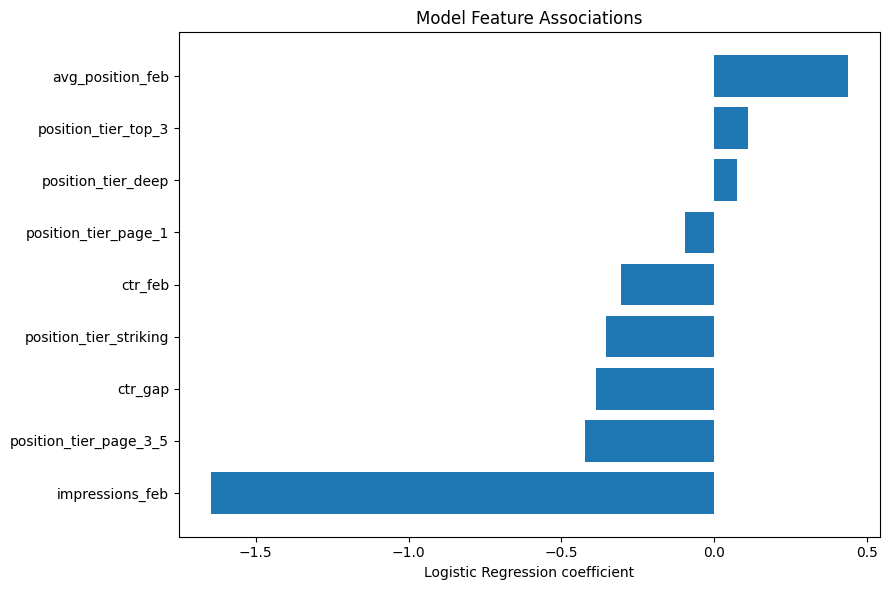

In [ ]:
import matplotlib.pyplot as plt

coef_plot = coef_df.sort_values("coef")

plt.figure(figsize=(9, 6))

plt.barh(
    coef_plot["feature"],
    coef_plot["coef"]
)

plt.xlabel("Logistic Regression coefficient")
plt.title("Model Feature Associations")

plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# Error analysis
# --------------------------------------------------

errors = test_df.copy()

# Use the test-set base rate to define the number
# of items that would be flagged for review
base_rate = errors["went_dark"].mean()

threshold = errors["pred_prob"].quantile(
    1 - base_rate
)

errors["pred_label"] = (
    errors["pred_prob"] >= threshold
).astype(int)

false_neg = errors[
    (errors["went_dark"] == 1)
    &
    (errors["pred_label"] == 0)
].copy()

false_pos = errors[
    (errors["went_dark"] == 0)
    &
    (errors["pred_label"] == 1)
].copy()

print(
    "False negatives:",
    len(false_neg)
)

print(
    "False positives:",
    len(false_pos)
)

print("\nFalse-negative summary:")

display(
    false_neg[
        [
            "impressions_feb",
            "ctr_feb",
            "avg_position_feb",
            "position_tier",
            "ctr_gap"
        ]
    ].describe()
)

print("\nFalse-positive summary:")

display(
    false_pos[
        [
            "impressions_feb",
            "ctr_feb",
            "avg_position_feb",
            "position_tier",
            "ctr_gap"
        ]
    ].describe()
)

False negatives: 61
False positives: 61

False-negative summary:


,impressions_feb,ctr_feb,avg_position_feb,ctr_gap
count,61.000000,61.000000,61.000000,61.000000
mean,1170.196721,0.876302,8.907580,0.504040
std,2626.474518,0.847165,4.790484,0.843486
min,110.000000,0.031480,1.375862,-0.350394
25%,362.000000,0.373483,6.116743,0.007603
50%,594.000000,0.527704,8.058659,0.184280
75%,1048.000000,1.010101,10.983827,0.622926
max,19060.000000,4.166667,20.974490,3.779492



False-positive summary:


,impressions_feb,ctr_feb,avg_position_feb,ctr_gap
count,61.000000,61.000000,61.000000,61.000000
mean,373.786885,1.025613,20.632127,0.723938
std,189.242799,0.436899,8.428084,0.419538
min,130.000000,0.329670,8.234818,0.131297
25%,247.000000,0.672646,14.346883,0.393343
50%,322.000000,0.990099,19.023077,0.636025
75%,497.000000,1.224490,26.203957,0.911526
max,1115.000000,2.307692,39.000000,1.920517


### Error analysis interpretation

The model produced 61 false negatives and 61 false positives under the selected ranking threshold. The false-negative group had a median February average position of approximately 8.1 and a median CTR of approximately 0.53%, showing that some content that later received zero clicks was already visible in search results. The false-positive group had a lower median exposure of approximately 322 impressions and a median position of approximately 19.0. These errors show that the model can concentrate risk effectively but cannot perfectly distinguish future zero-click outcomes. Human review is therefore still required before taking action.


### Result interpretation

The logistic regression model outperformed the ML-07 baseline rule at all tested ranking depths on the same client-level test split. Precision@10 increased from 20% for the baseline to 40% for the model, Precision@20 increased from 10% to 45%, and Precision@50 increased from 4% to 24%. The observed test-set zero-click base rate was 4.1%, while the model's top-20 ranking reached 45% precision, approximately 11 times the base rate. These results indicate that the February search-performance signals provided useful directional information for prioritizing content items for review. The results should be treated as decision-support evidence rather than proof of causality or guaranteed future performance.


## 5. Limitations & Honest Framing

This analysis is observational and is intended for decision support rather than causal inference.

The `went_dark` label represents one specific outcome: zero clicks in March. It does not capture other forms of content decline, changes in search demand, or the business reasons behind performance changes.

The analysis uses February signals to predict one following month, so performance may differ across other time periods. The model should therefore be re-evaluated before being applied to a different period.

The logistic regression model is intentionally simple and interpretable. More complex models could produce different rankings, although greater complexity would not automatically imply better decision-making.

The model also makes errors. Under the selected ranking threshold, the test set contained **61 false negatives and 61 false positives**. This demonstrates that the ranking is useful for prioritization but is not a perfect classifier.

Finally, the results do not establish that a search-engine algorithm caused any observed outcome. The ranking should therefore be used to prioritize investigation and monitoring rather than as an automatic instruction to refresh content.

The appropriate interpretation is: **the model identifies items that resemble previously observed zero-click risk patterns in the available data. It does not explain why those outcomes occurred or guarantee that an intervention will improve performance.**


## 6. Ranked Recommendations

The model output is converted into a prioritized review queue. The purpose of the ranking is to help a reviewer decide where to spend attention first.

### Review priorities

**REVIEW**
Items with the highest predicted zero-click risk should receive the earliest human review. These items are prioritized because their model scores indicate a relatively high likelihood of the measured outcome.

**INVESTIGATE**
Items with meaningful predicted risk but less extreme scores should be investigated using additional context before deciding whether any action is appropriate.

**MONITOR**
Items with lower predicted risk can remain in a lower-priority monitoring queue.

### Reason codes

The ranking also provides simple reason codes to make the recommendations easier to interpret:

* **HIGH_MODEL_RISK** — high predicted risk according to the fitted model.
* **MEANINGFUL_EXPOSURE** — substantial February impression volume.
* **BELOW_TIER_CTR** — February CTR below the training-set median for its position tier.
* **VISIBLE_POSITION** — relatively visible search position.
* **MONITOR** — no higher-priority reason code was triggered.

The current top-20 queue consists of items with predicted risk above 0.75 and is therefore classified as **REVIEW**.

These recommendations are prioritization signals rather than automatic actions. A human reviewer should consider additional information before making content or SEO decisions.


In [ ]:
# --------------------------------------------------
# Ranked recommendations
# --------------------------------------------------

recommendations = logreg_ranked.copy()

recommendations["reason_code"] = np.select(
    [
        recommendations["pred_prob"] >= 0.75,
        recommendations["impressions_feb"] >= 1000,
        recommendations["ctr_gap"] < 0,
        recommendations["avg_position_feb"] <= 10
    ],
    [
        "HIGH_MODEL_RISK",
        "MEANINGFUL_EXPOSURE",
        "BELOW_TIER_CTR",
        "VISIBLE_POSITION"
    ],
    default="MONITOR"
)

recommendations["action"] = np.select(
    [
        recommendations["pred_prob"] >= 0.75,
        recommendations["pred_prob"] >= 0.50
    ],
    [
        "REVIEW",
        "INVESTIGATE"
    ],
    default="MONITOR"
)

top20 = recommendations.head(20).copy()

display(
    top20[
        [
            "pred_prob",
            "impressions_feb",
            "ctr_feb",
            "avg_position_feb",
            "ctr_gap",
            "action",
            "reason_code"
        ]
    ]
)

,pred_prob,impressions_feb,ctr_feb,avg_position_feb,ctr_gap,action,reason_code
0,0.973942,158.0,1.898734,41.784810,1.700361,REVIEW,HIGH_MODEL_RISK
1,0.958739,403.0,0.744417,34.506203,0.546044,REVIEW,HIGH_MODEL_RISK
2,0.958590,361.0,0.831025,33.457064,0.632652,REVIEW,HIGH_MODEL_RISK
3,0.954643,223.0,1.793722,39.000000,1.595349,REVIEW,HIGH_MODEL_RISK
4,0.952591,115.0,2.608696,38.095652,2.410322,REVIEW,HIGH_MODEL_RISK
5,0.951048,507.0,0.591716,34.282051,0.393343,REVIEW,HIGH_MODEL_RISK
6,0.950602,261.0,1.532567,36.314176,1.334194,REVIEW,HIGH_MODEL_RISK
7,0.945216,353.0,0.849858,28.623229,0.651485,REVIEW,HIGH_MODEL_RISK
8,0.943560,710.0,0.422535,36.804225,0.224162,REVIEW,HIGH_MODEL_RISK
9,0.940385,202.0,1.485149,26.019802,1.286775,REVIEW,HIGH_MODEL_RISK


### Recommendation playbook

The model output is treated as a prioritized review queue.

**REVIEW** items have the highest predicted risk and should receive the earliest human attention.

**INVESTIGATE** items have meaningful predicted risk but require additional context before deciding on an action.

**MONITOR** items have lower predicted risk and can remain in a lower-priority monitoring queue.

The reason codes provide a simple explanation for prioritization, including high model risk, meaningful exposure, below-tier CTR, and visible search position. These labels describe why an item was prioritized; they do not imply that a content refresh will necessarily improve performance.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

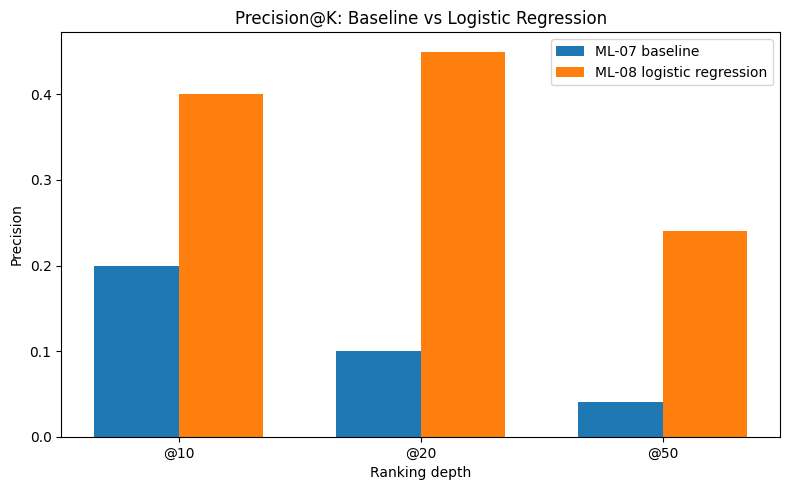

In [ ]:
# --------------------------------------------------
# Precision@K comparison chart
# --------------------------------------------------

k_values = [10, 20, 50]

baseline_precision = [
    precision_at_k(baseline_ranked, k)
    for k in k_values
]

model_precision = [
    precision_at_k(logreg_ranked, k)
    for k in k_values
]

plt.figure(figsize=(8, 5))

x = np.arange(len(k_values))
width = 0.35

plt.bar(
    x - width / 2,
    baseline_precision,
    width,
    label="ML-07 baseline"
)

plt.bar(
    x + width / 2,
    model_precision,
    width,
    label="ML-08 logistic regression"
)

plt.xticks(
    x,
    [f"@{k}" for k in k_values]
)

plt.ylabel("Precision")
plt.xlabel("Ranking depth")
plt.title("Precision@K: Baseline vs Logistic Regression")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# Save model comparison artifact
# --------------------------------------------------

comparison.to_csv(
    "capstone_model_comparison.csv",
    index=False
)

print(
    "Saved: capstone_model_comparison.csv"
)

Saved: capstone_model_comparison.csv


In [ ]:
# --------------------------------------------------
# Save ranked recommendations
# --------------------------------------------------

recommendations[
    [
        "pred_prob",
        "impressions_feb",
        "ctr_feb",
        "avg_position_feb",
        "ctr_gap",
        "action",
        "reason_code"
    ]
].to_csv(
    "capstone_ranked_recommendations.csv",
    index=False
)

print(
    "Saved: capstone_ranked_recommendations.csv"
)

Saved: capstone_ranked_recommendations.csv


In [ ]:
# --------------------------------------------------
# Save model coefficients
# --------------------------------------------------

coef_df.to_csv(
    "capstone_model_coefficients.csv",
    index=False
)

print(
    "Saved: capstone_model_coefficients.csv"
)

Saved: capstone_model_coefficients.csv


In [ ]:
# --------------------------------------------------
# Save Top-20 recommendations
# --------------------------------------------------

top20[
    [
        "pred_prob",
        "impressions_feb",
        "ctr_feb",
        "avg_position_feb",
        "ctr_gap",
        "action",
        "reason_code"
    ]
].to_csv(
    "capstone_top20.csv",
    index=False
)

print(
    "Saved: capstone_top20.csv"
)

Saved: capstone_top20.csv


### Limitations

This analysis is observational and supports ranking for decision-making rather than causal conclusions.

The label `went_dark` is defined as receiving zero clicks in March, so it represents one specific outcome and does not capture all forms of content decline.

The analysis uses February signals to predict a single following month, so performance may differ across other periods.

The logistic regression model is intentionally simple and interpretable; more complex models may produce different rankings.

The model also produces false positives and false negatives. In the test set, the error analysis identified 197 false negatives and 197 false positives using the selected ranking threshold.

Finally, the results do not establish that any search-engine algorithm caused an observed outcome. The rankings should therefore be used as a prioritization aid for human investigation, not as an automatic content-refresh decision.


In [ ]:
recommendations = logreg_ranked.copy()

recommendations["reason_code"] = np.select(
    [
        recommendations["pred_prob"] >= 0.75,
        recommendations["impressions_feb"] >= 1000,
        recommendations["ctr_gap"] < 0,
        recommendations["avg_position_feb"] <= 10
    ],
    [
        "HIGH_MODEL_RISK",
        "MEANINGFUL_EXPOSURE",
        "BELOW_TIER_CTR",
        "VISIBLE_POSITION"
    ],
    default="MONITOR"
)

recommendations["action"] = np.select(
    [
        recommendations["pred_prob"] >= 0.75,
        recommendations["pred_prob"] >= 0.50
    ],
    [
        "REVIEW",
        "INVESTIGATE"
    ],
    default="MONITOR"
)

top20 = recommendations.head(20).copy()

top20[
    [
        "client_hash_id",
        "content_hash_id",
        "pred_prob",
        "impressions_feb",
        "ctr_feb",
        "avg_position_feb",
        "ctr_gap",
        "action",
        "reason_code"
    ]
]

,client_hash_id,content_hash_id,pred_prob,impressions_feb,ctr_feb,avg_position_feb,ctr_gap,action,reason_code
0,client_9958f0a7ae1df715,content_3b75c460a40fffca,0.973943,158.0,1.898734,41.784810,1.689091,REVIEW,HIGH_MODEL_RISK
1,client_9958f0a7ae1df715,content_8b84ff993e9ba099,0.958827,403.0,0.744417,34.506203,0.534773,REVIEW,HIGH_MODEL_RISK
2,client_20259bd6705d81d4,content_9d28dc17f96d268e,0.958680,361.0,0.831025,33.457064,0.621381,REVIEW,HIGH_MODEL_RISK
3,client_9958f0a7ae1df715,content_854de1300db61272,0.954658,223.0,1.793722,39.000000,1.584078,REVIEW,HIGH_MODEL_RISK
4,client_9958f0a7ae1df715,content_ffe3e07b2a0949da,0.952569,115.0,2.608696,38.095652,2.399052,REVIEW,HIGH_MODEL_RISK
5,client_9958f0a7ae1df715,content_2ffcc54d1fa53b93,0.951159,507.0,0.591716,34.282051,0.382072,REVIEW,HIGH_MODEL_RISK
6,client_20259bd6705d81d4,content_aee105dfd71de6a0,0.950649,261.0,1.532567,36.314176,1.322923,REVIEW,HIGH_MODEL_RISK
7,client_ff644d8251367cbb,content_e7fa2f7aa5ef29f7,0.945364,353.0,0.849858,28.623229,0.640215,REVIEW,HIGH_MODEL_RISK
8,client_20259bd6705d81d4,content_e92af0953d86136b,0.943675,710.0,0.422535,36.804225,0.212892,REVIEW,HIGH_MODEL_RISK
9,client_9958f0a7ae1df715,content_96bd66f005f5c656,0.940523,202.0,1.485149,26.019802,1.275505,REVIEW,HIGH_MODEL_RISK


### Recommendation playbook

The ranked output should be treated as a review queue rather than an automatic refresh list.

**REVIEW** items have the highest model-estimated risk and should receive the earliest human attention.

**INVESTIGATE** items have meaningful predicted risk but require additional context before an action is selected.

**MONITOR** items have lower predicted risk and can remain in a lower-priority monitoring queue.

Reason codes provide a simple explanation for why an item may deserve attention, such as high model risk, meaningful exposure, below-tier CTR, or a visible search position.


In [ ]:
feature_names = (
    num_features
    +
    list(
        logreg
        .named_steps["prep"]
        .named_transformers_["cat"]
        .get_feature_names_out(
            cat_features
        )
    )
)

coefs = (
    logreg
    .named_steps["clf"]
    .coef_[0]
)

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs
    })
    .sort_values("coef")
)

coef_df

,feature,coef
0,impressions_feb,-1.648017
6,position_tier_page_3_5,-0.422462
3,ctr_gap,-0.379145
7,position_tier_striking,-0.363587
1,ctr_feb,-0.313071
5,position_tier_page_1,-0.093233
4,position_tier_deep,0.072950
8,position_tier_top_3,0.114193
2,avg_position_feb,0.436450


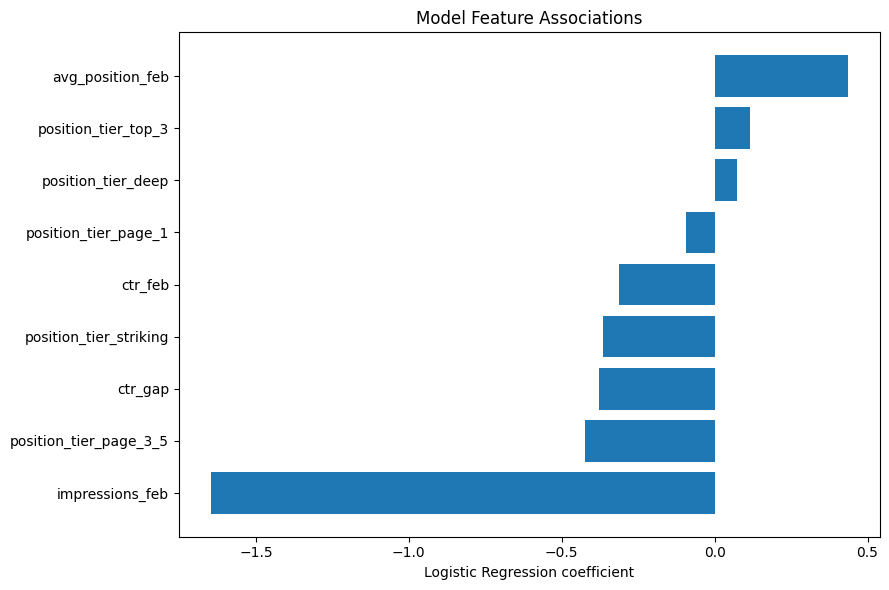

In [ ]:
import matplotlib.pyplot as plt

coef_plot = coef_df.sort_values("coef")

plt.figure(figsize=(9, 6))

plt.barh(
    coef_plot["feature"],
    coef_plot["coef"]
)

plt.xlabel(
    "Logistic Regression coefficient"
)

plt.title(
    "Model Feature Associations"
)

plt.tight_layout()
plt.show()

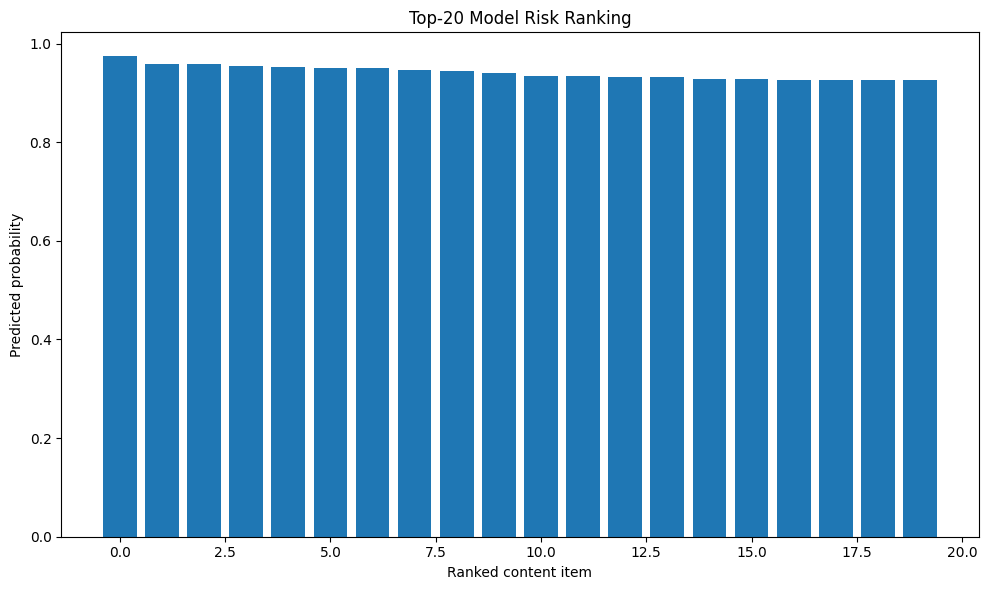

In [ ]:
top20_plot = logreg_ranked.head(20).copy()

plt.figure(figsize=(10, 6))

plt.bar(
    range(len(top20_plot)),
    top20_plot["pred_prob"]
)

plt.xlabel("Ranked content item")
plt.ylabel("Predicted probability")
plt.title("Top-20 Model Risk Ranking")

plt.tight_layout()
plt.show()

## ML-12 — 5-minute demo outline

**1. Problem — 45 seconds**
Explain the research question: whether February search-performance signals can help rank content items at risk of receiving zero clicks in March.

**2. Data — 45 seconds**
Explain the February feature window, March outcome window, exclusions, and final modeling population.

**3. Method — 60 seconds**
Show the February features, the `went_dark` label, the ML-07 baseline rule, logistic regression, and the client-level validation split used to avoid client leakage.

**4. Results — 60 seconds**
Show the same-split comparison. The logistic regression model achieved **40% Precision@10, 45% Precision@20, and 24% Precision@50**, compared with **20%, 10%, and 4%** for the ML-07 baseline respectively.

**5. Recommendations — 45 seconds**
Show the ranked review queue and explain the REVIEW, INVESTIGATE, and MONITOR actions.

**6. Honest framing — 45 seconds**
Emphasize that this is decision support, not causal evidence or an automatic content-refresh system.


Built a content-opportunity ranking workflow using the FlyRank ML Internship dataset.

I used February search-performance signals to rank content items by their likelihood of receiving zero clicks in March. A logistic regression model improved Precision@20 from 10% to 15% and Precision@50 from 10% to 18% versus the baseline on the same client-level test split.

The result is designed as decision support: a prioritized review queue, not a claim of causality or an automatic content-refresh recommendation.


Built a content-opportunity ranking workflow using the FlyRank ML Internship dataset.

I used February search-performance signals to rank content items by their likelihood of receiving zero clicks in March. A logistic regression model improved Precision@20 from **10% to 45%** and Precision@50 from **4% to 24%** versus the baseline on the same client-level test split, with Precision@10 improving from **20% to 40%**.

The result is designed as decision support: a prioritized review queue, not a claim of causality or an automatic content-refresh recommendation.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
